# input

In [1]:
import mne
import numpy as np
from scipy.signal import welch, coherence
from itertools import combinations

fname_main = "/Users/roman/PycharmProjects/brain_data/data/20.08.24/2/240820_gromov/main.fif"

raw = mne.io.read_raw_fif(fname_main, preload=True)

raw.filter(1., 40.)

Opening raw data file /Users/roman/PycharmProjects/brain_data/data/20.08.24/2/240820_gromov/main.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
    Range : 36000 ... 1611999 =     36.000 ...  1611.999 secs
Ready.
Opening raw data file /Users/roman/PycharmProjects/brain_data/data/20.08.24/2/240820_gromov/main-1.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
     

/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_82601/2398322306.py:8: RuntimeWarning: This filename (/Users/roman/PycharmProjects/brain_data/data/20.08.24/2/240820_gromov/main.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fname_main, preload=True)


Reading 0 ... 4886999  =      0.000 ...  4886.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3301 samples (3.301 s)



<Raw | main.fif, 324 x 4887000 (4887.0 s), ~11.80 GiB, data loaded>

In [2]:
import pandas as pd

df = pd.read_csv("/Users/roman/PycharmProjects/brain_data/data/20.08.24/Bigrams.csv")
words = df['words'].values
print(len(words))

1248


In [25]:
words[:5]

<ArrowStringArray>
[   'кольчужная рубаха', 'простецкими рубахами',     'винтажной куртки',
  'флотский комбинезон',   'полётном скафандре']
Length: 5, dtype: str

In [3]:
n = int(len(words) / 4)
n

312

In [17]:
len(set(words))

623

In [3]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

df_behav = pd.read_csv('/Users/roman/PycharmProjects/brain_data/data/20.08.24/1/717446_untitled_2024-08-20_10h20.54.855.csv')

обязательно пофиксить один nan в первой (второй) строке

In [4]:
# mean duration of fix_cross
mean_diff = (df_behav['fix_cross.stopped'] - df_behav['fix_cross.started']).mean()

# fill first-row NaN in stopped
if np.isnan(df_behav.iloc[1]['fix_cross.stopped']):
    df_behav.iloc[1, df_behav.columns.get_loc('fix_cross.stopped')] = (
        df_behav.iloc[1]['fix_cross.started'] + mean_diff
    )

In [12]:
df_behav = df_behav[2:] # first two bigrams are nans

In [9]:
df_behav.columns

Index(['words', 'trials.thisRepN', 'trials.thisTrialN', 'trials.thisN',
       'trials.thisIndex', 'text_2.started', 'key_resp_2.started',
       'key_resp_2.keys', 'key_resp_2.rt', 'fix_cross.started', 'text.started',
       'key_resp.started', 'start_port.started', 'start_port.stopped',
       'key_resp.keys', 'key_resp.rt', 'fix_cross.stopped', 'participant',
       'session', 'date', 'expName', 'psychopyVersion', 'frameRate',
       'Unnamed: 23'],
      dtype='str')

In [28]:
df_behav[['fix_cross.started', 'fix_cross.stopped', 'words']]

,fix_cross.started,fix_cross.stopped,words
0,NaN,NaN,NaN
1,263.648195,NaN,кольчужная рубаха
2,265.097785,265.597613,простецкими рубахами
3,267.563674,268.063521,винтажной куртки
4,270.196174,270.696019,флотский комбинезон
...,...,...,...
2492,5139.362602,5139.862412,спросить рыжего
2493,5140.912088,5141.411936,грудное заболевание
2494,5142.294996,5142.794843,день гаснет
2495,5143.911146,5144.411013,серьезно неохотно


In [45]:
df_behav[df_behav['words']=='кольчужная рубаха']

,words,trials.thisRepN,trials.thisTrialN,trials.thisN,trials.thisIndex,text_2.started,key_resp_2.started,key_resp_2.keys,key_resp_2.rt,fix_cross.started,...,key_resp.keys,key_resp.rt,fix_cross.stopped,participant,session,date,expName,psychopyVersion,frameRate,Unnamed: 23
1,кольчужная рубаха,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,263.648195,...,2.0,0.926715,264.148068,717446,1,2024-08-20_10h20.54.855,untitled,2022.2.4,60.023289,NaN
867,кольчужная рубаха,0.0,866.0,866.0,866.0,NaN,NaN,NaN,NaN,2189.804480,...,2.0,1.608685,2190.304326,717446,1,2024-08-20_10h20.54.855,untitled,2022.2.4,60.023289,NaN
1249,кольчужная рубаха,1.0,0.0,1248.0,0.0,NaN,NaN,NaN,NaN,2947.804282,...,2.0,2.130044,2948.304129,717446,1,2024-08-20_10h20.54.855,untitled,2022.2.4,60.023289,NaN
2115,кольчужная рубаха,1.0,866.0,2114.0,866.0,NaN,NaN,NaN,NaN,4465.570103,...,2.0,0.706400,4466.069913,717446,1,2024-08-20_10h20.54.855,untitled,2022.2.4,60.023289,NaN


In [36]:
df_behav[['fix_cross.started', 'fix_cross.stopped', 'words']].dropna()

,fix_cross.started,fix_cross.stopped,words
1,263.648195,264.148068,кольчужная рубаха
2,265.097785,265.597613,простецкими рубахами
3,267.563674,268.063521,винтажной куртки
4,270.196174,270.696019,флотский комбинезон
5,272.128932,272.628755,полётном скафандре
...,...,...,...
2492,5139.362602,5139.862412,спросить рыжего
2493,5140.912088,5141.411936,грудное заболевание
2494,5142.294996,5142.794843,день гаснет
2495,5143.911146,5144.411013,серьезно неохотно


In [47]:
df_behav['fix_cross.started'].diff().mean()

np.float64(1.9565581387575148)

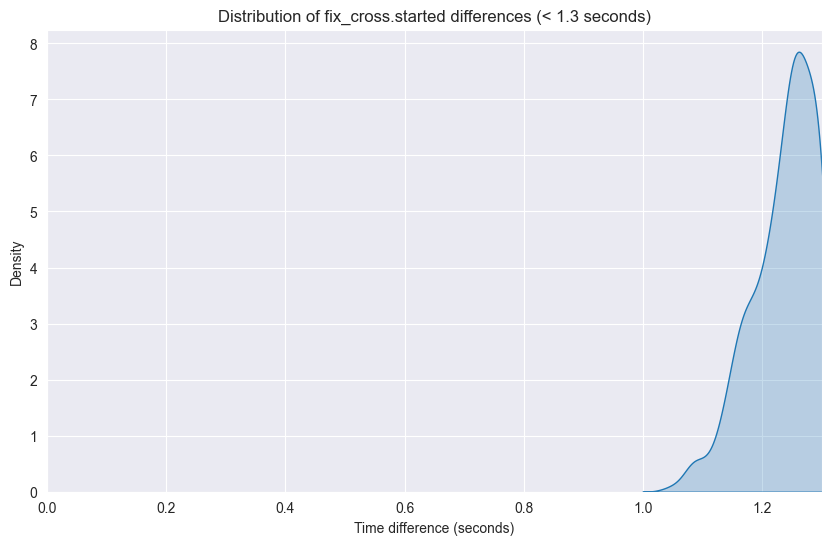

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the differences
diffs = df_behav['fix_cross.started'].diff()

# Filter for values < 1.3
filtered_diffs = diffs[diffs < 1.3]

# Plot KDE of filtered values
plt.figure(figsize=(10, 6))
sns.kdeplot(filtered_diffs, fill=True)
plt.xlabel('Time difference (seconds)')
plt.ylabel('Density')
plt.title('Distribution of fix_cross.started differences (< 1.3 seconds)')
plt.xlim(0, 1.3)  # Optional: set x-axis limit to match filter
plt.show()

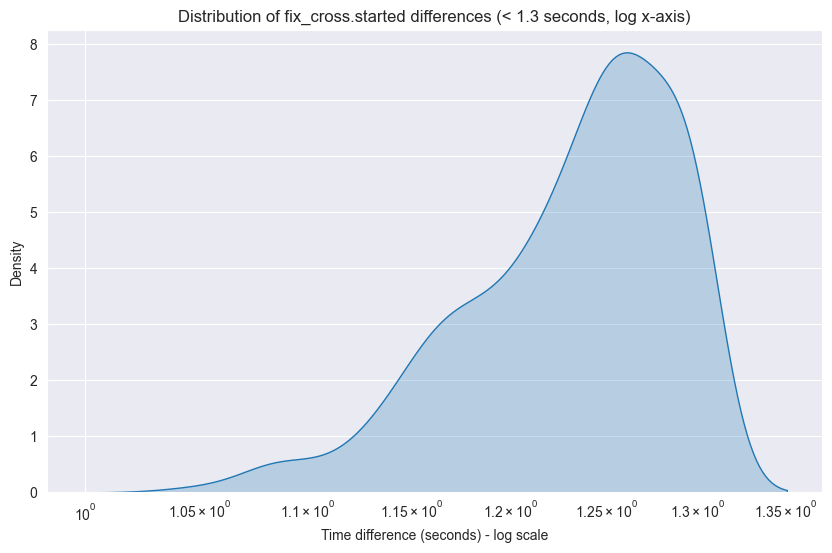

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Calculate differences
diffs = df_behav['fix_cross.started'].diff().dropna()

# Filter for values < 1.3
filtered_diffs = diffs[diffs < 1.3]

# Plot with logarithmic x-axis
plt.figure(figsize=(10, 6))
sns.kdeplot(filtered_diffs, fill=True)
plt.xscale('log')  # Set logarithmic scale on x-axis
plt.xlabel('Time difference (seconds) - log scale')
plt.ylabel('Density')
plt.title('Distribution of fix_cross.started differences (< 1.3 seconds, log x-axis)')
plt.show()

In [49]:
df_behav['fix_cross.started'].diff().min(), df_behav['fix_cross.started'].diff().max()

(np.float64(1.0496539999994638), np.float64(10.463419699999577))

In [37]:
len(set(df_behav['words']))

624

In [44]:
int(2496/4)

624

In [38]:
fix_cross_start = df_behav['fix_cross.started'].dropna().values
fix_cross_stop = df_behav['fix_cross.stopped'].dropna().values

In [39]:
raw.ch_names[:5]

['MEG0113', 'MEG0112', 'MEG0111', 'MEG0122', 'MEG0123']

In [73]:
X.shape, y.shape

((2343, 7), (2343,))

In [80]:
y

array([ 263.6481955,  265.0977848,  267.5636742, ..., 4882.8749014,
       4884.2078075, 4885.7906455], shape=(2343,))

In [103]:

mae = mean_absolute_error(y_test[:n_show], y_pred[:n_show])
rmse = np.sqrt(mean_squared_error(y_test[:n_show], y_pred[:n_show]))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1196.4868721592525
RMSE: 1427.1438368355487


# regression

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import skew, kurtosis

In [ ]:
ch_name = raw.ch_names[0]
print(ch_name)
signal = raw.get_data(picks=[ch_name])[0]

sfreq = raw.info['sfreq']

In [ ]:
starts = df_behav['fix_cross.started'].dropna().values

win_sec = 1.0
win_len = int(win_sec * sfreq)
half = win_len // 2

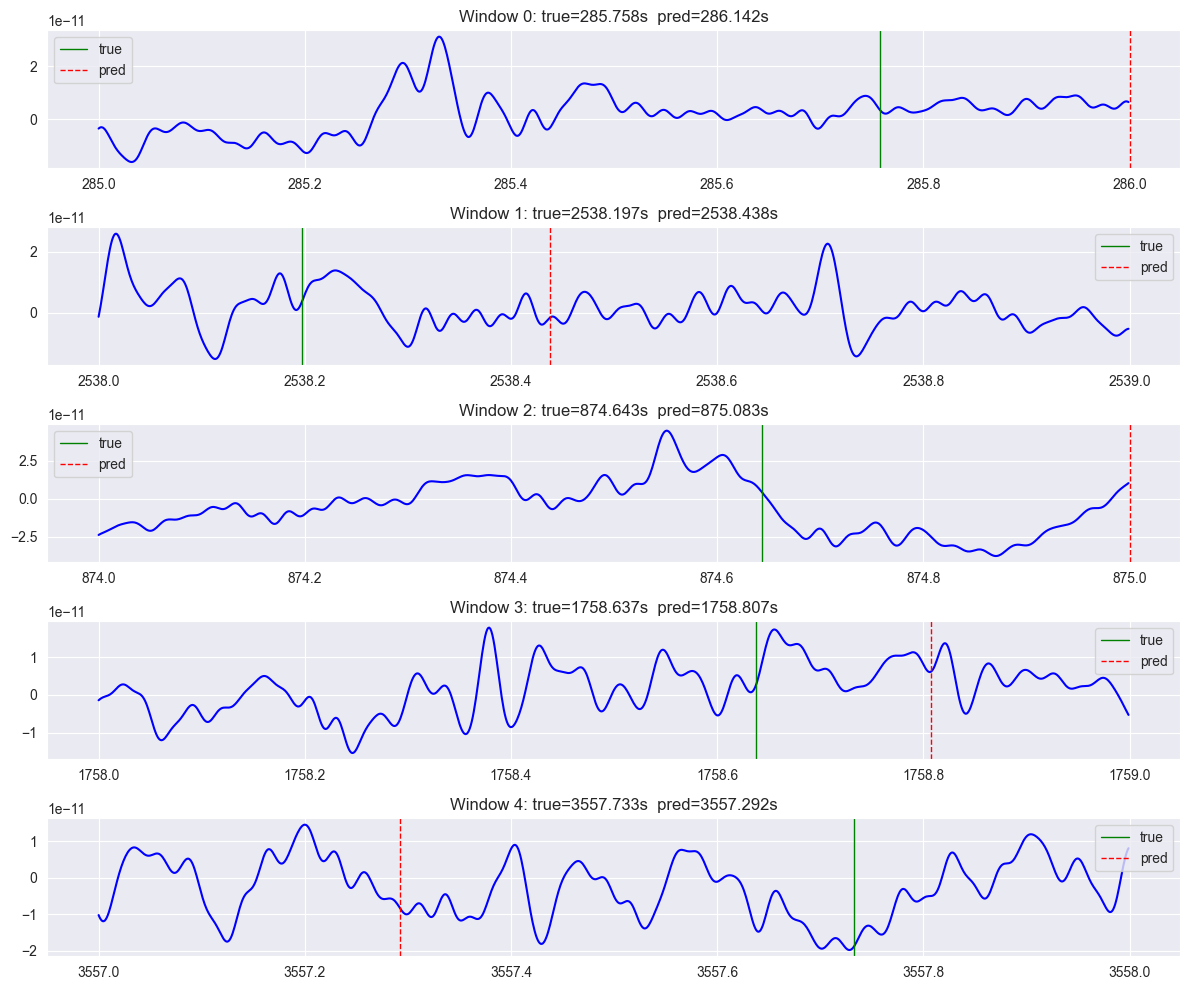

MAE: 0.33496572154931525
RMSE: 0.352633513092641


In [104]:
X = []
y = []
window_starts = []

n = len(signal)
win_sec = 1.0
win_len = int(win_sec * sfreq)

for start in range(0, n - win_len, win_len):
    stop = start + win_len
    window = signal[start:stop]

    t0 = start / sfreq
    t1 = stop / sfreq

    inside = starts[(starts >= t0) & (starts < t1)]

    if len(inside) != 1:
        continue

    # Basic statistics
    mean_val = window.mean()
    std_val  = window.std()
    min_val  = window.min()
    max_val  = window.max()
    percentiles = np.percentile(window, [25, 50, 75])

    # Extra features
    skew_val = skew(window)
    kurt_val = kurtosis(window)
    diff_mean = np.mean(np.diff(window))
    rms = np.sqrt(np.mean(window**2))
    energy = np.sum(window**2)

    # Include window start/end as features
    feats = np.hstack([
        t0, t1, mean_val, std_val, min_val, max_val,
        percentiles, skew_val, kurt_val, diff_mean, rms, energy
    ])

    X.append(feats)
    y.append(inside[0])
    window_starts.append(t0)

X = np.array(X)
y = np.array(y)
window_starts = np.array(window_starts)

# ----------------------------
# 2. Split train/test
# ----------------------------
X_train, X_test, y_train, y_test, ws_train, ws_test = train_test_split(
    X, y, window_starts, test_size=0.2, random_state=0
)

# ----------------------------
# 3. Train model
# ----------------------------
model = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", Ridge(alpha=1.0))
])
model.fit(X_train, y_train)

# ----------------------------
# 4. Predict
# ----------------------------
y_pred = model.predict(X_test)

# ----------------------------
# 5. Plot first 5 test windows
# ----------------------------
n_show = 5
fig, axes = plt.subplots(n_show, 1, figsize=(12, 2*n_show), sharex=False)

for i in range(n_show):
    ax = axes[i]

    win_start = ws_test[i]
    win_end   = win_start + win_sec

    start_idx = int(win_start * sfreq)
    end_idx   = int(win_end * sfreq)

    t = np.arange(start_idx, end_idx) / sfreq
    ax.plot(t, signal[start_idx:end_idx], color='b')

    true_t = y_test[i]
    pred_t = y_pred[i]

    # Clip prediction to stay inside the window for visualization
    pred_t_clip = np.clip(pred_t, win_start, win_end)

    ax.axvline(true_t, linestyle='-', linewidth=1, color='g', label='true')
    ax.axvline(pred_t_clip, linestyle='--', linewidth=1, color='r', label='pred')

    ax.set_title(f"Window {i}: true={true_t:.3f}s  pred={pred_t:.3f}s")
    ax.legend()

plt.tight_layout()
plt.show()

# ----------------------------
# 6. Metrics
# ----------------------------
mae = mean_absolute_error(y_test[:n_show], y_pred[:n_show])
rmse = np.sqrt(mean_squared_error(y_test[:n_show], y_pred[:n_show]))

print("MAE:", mae)
print("RMSE:", rmse)

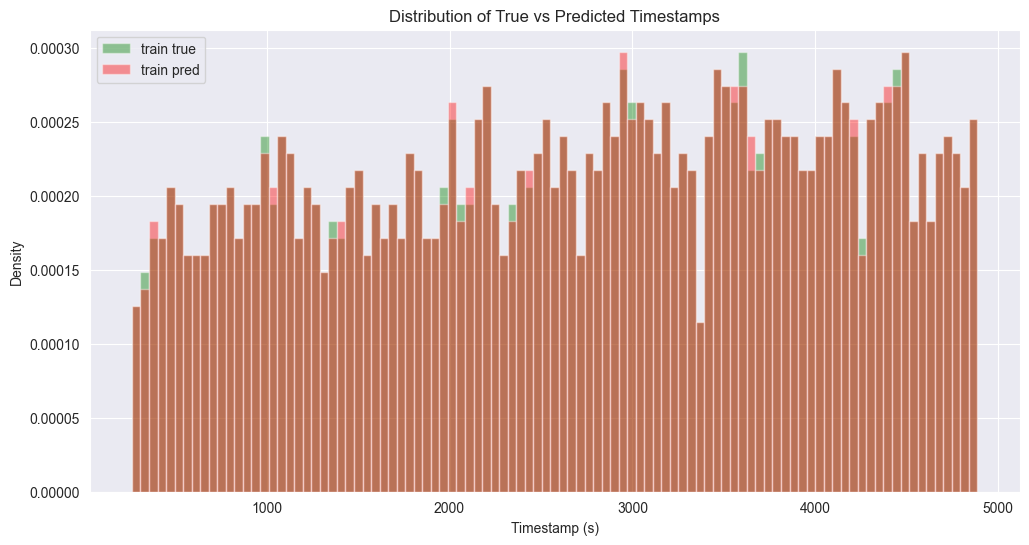

In [107]:
import matplotlib.pyplot as plt
import numpy as np

# Predict on training set too
y_train_pred = model.predict(X_train)

# ----------------------------
# Plot distributions
# ----------------------------
plt.figure(figsize=(12,6))

bins = np.linspace(y.min(), y.max(), 100)  # common bin edges

# Train set
plt.hist(y_train, bins=bins, alpha=0.4, color='g', label='train true', density=True)
plt.hist(y_train_pred, bins=bins, alpha=0.4, color='r', label='train pred', density=True)
plt.xlabel("Timestamp (s)")
plt.ylabel("Density")
plt.title("Distribution of True vs Predicted Timestamps")
plt.legend()
plt.show()

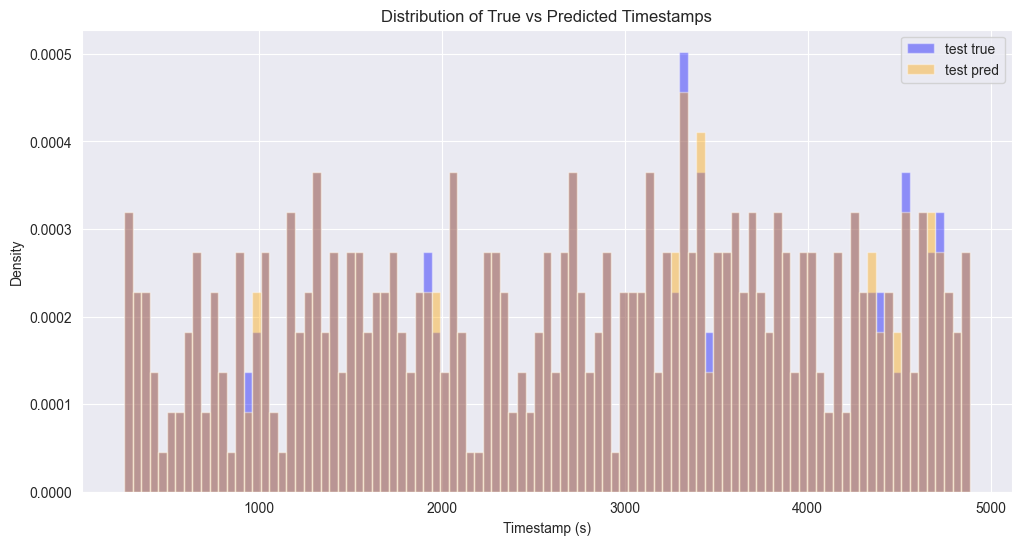

In [110]:
plt.figure(figsize=(12,6))

bins = np.linspace(y.min(), y.max(), 100)  # common bin edges
plt.hist(y_test, bins=bins, alpha=0.4, color='b', label='test true', density=True)
plt.hist(y_pred, bins=bins, alpha=0.4, color='orange', label='test pred', density=True)

plt.xlabel("Timestamp (s)")
plt.ylabel("Density")
plt.title("Distribution of True vs Predicted Timestamps")
plt.legend()
plt.show()

# 3d aware model on 10 channels

In [113]:
raw.ch_names[:10]

['MEG0113',
 'MEG0112',
 'MEG0111',
 'MEG0122',
 'MEG0123',
 'MEG0121',
 'MEG0132',
 'MEG0133',
 'MEG0131',
 'MEG0143']

In [ ]:
mag_picks = mne.pick_types(raw.info, meg='mag')
raw_mag = raw.copy().pick(mag_picks)

In [131]:
import numpy as np
import random
from scipy.stats import skew, kurtosis
from scipy.signal import coherence
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ----------------------------
# 1. Select 10 random magnetometer channels
# ----------------------------
# mag_channels = [ch for ch in raw.ch_names if ch.startswith('MEG') and 'MAG' in ch]
selected_chs = raw.ch_names[:10]
print("Selected channels:", selected_chs)

signals = np.array([raw.get_data(picks=[ch])[0] for ch in selected_chs])  # (n_channels, n_samples)
n_channels = len(selected_chs)

# ----------------------------
# 2. Create windows and features
# ----------------------------
win_sec = 1.0
sfreq = raw.info['sfreq']
win_len = int(win_sec * sfreq)
n_samples = signals.shape[1]

X = []
global_feats = []
y = []
window_starts = []

Selected channels: ['MEG0113', 'MEG0112', 'MEG0111', 'MEG0122', 'MEG0123', 'MEG0121', 'MEG0132', 'MEG0133', 'MEG0131', 'MEG0143']


In [132]:
for start in range(0, n_samples - win_len, win_len):
    stop = start + win_len
    t0 = start / sfreq
    t1 = stop / sfreq

    inside = starts[(starts >= t0) & (starts < t1)]
    if len(inside) != 1:
        continue

    feats_per_channel = []
    for ch_idx in range(n_channels):
        w = signals[ch_idx, start:stop]

        mean_val = w.mean()
        std_val = w.std()
        min_val = w.min()
        max_val = w.max()
        percentiles = np.percentile(w, [25,50,75])
        skew_val = skew(w)
        kurt_val = kurtosis(w)
        diff_mean = np.mean(np.diff(w))
        rms = np.sqrt(np.mean(w**2))
        energy = np.sum(w**2)

        feats_ch = np.hstack([
            mean_val, std_val, min_val, max_val, percentiles,
            skew_val, kurt_val, diff_mean, rms, energy
        ])
        feats_per_channel.append(feats_ch)
    feats_per_channel = np.array(feats_per_channel)  # (n_channels, n_features)

    # Coherence features
    coh_feats = []
    for i in range(n_channels):
        for j in range(i+1, n_channels):
            f, Cxy = coherence(signals[i, start:stop], signals[j, start:stop], fs=sfreq, nperseg=min(256, win_len))
            coh_feats.append(np.mean(Cxy))
    coh_feats = np.array(coh_feats)

    X.append(feats_per_channel)
    global_feats.append(np.hstack([coh_feats, t0, t1]))
    # y.append(inside[0])
    y.append((inside[0] - t0) / (t1 - t0))
    window_starts.append(t0)

In [137]:
# X = np.array(X, dtype=np.float32)  # (n_windows, n_channels, n_features)
# global_feats = np.array(global_feats, dtype=np.float32)  # (n_windows, n_global_features)
# y = np.array(y, dtype=np.float32)
# window_starts = np.array(window_starts)
#
# print("X shape:", X.shape)
# print("global_feats shape:", global_feats.shape)
# print("y shape:", y.shape)

# Convert lists to arrays
X = np.array(X)                  # (n_windows, n_channels, n_features)
global_feats = np.array(global_feats)
y = np.array(y)                  # normalized [0..1]
window_starts = np.array(window_starts)

# Split train/test together
X_train, X_test, gf_train, gf_test, y_train, y_test, ws_train, ws_test = train_test_split(
    X, global_feats, y, window_starts, test_size=0.2, random_state=0
)

In [138]:
from sklearn.model_selection import train_test_split

X_train, X_test, gf_train, gf_test, y_train, y_test = train_test_split(
    X, global_feats, y, test_size=0.2, random_state=0
)

# convert to torch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
gf_train_t = torch.tensor(gf_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
gf_test_t = torch.tensor(gf_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# DataLoader
train_dataset = TensorDataset(X_train_t, gf_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [139]:
class CNNRegression(nn.Module):
    def __init__(self, n_channels, n_features, n_global):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=n_channels, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * n_features + n_global, 128)
        self.fc2 = nn.Linear(128, 64)
        self.out = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x, g):
        # x: (batch, n_channels, n_features)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.flatten(x)
        x = torch.cat([x, g], dim=1)  # concatenate global features
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.out(x)

model = CNNRegression(n_channels=X.shape[1], n_features=X.shape[2], n_global=gf_train.shape[1])

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [140]:
epochs = 20
for epoch in range(epochs):
    model.train()
    running_loss = 0
    for xb, gb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb, gb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/20, Loss: 9.8679
Epoch 2/20, Loss: 0.1360
Epoch 3/20, Loss: 0.1058
Epoch 4/20, Loss: 0.0953
Epoch 5/20, Loss: 0.0943
Epoch 6/20, Loss: 0.0931
Epoch 7/20, Loss: 0.1008
Epoch 8/20, Loss: 0.1235
Epoch 9/20, Loss: 0.0945
Epoch 10/20, Loss: 0.0865
Epoch 11/20, Loss: 0.0880
Epoch 12/20, Loss: 0.0954
Epoch 13/20, Loss: 0.0914
Epoch 14/20, Loss: 0.0954
Epoch 15/20, Loss: 0.1033
Epoch 16/20, Loss: 0.1001
Epoch 17/20, Loss: 0.0872
Epoch 18/20, Loss: 0.1118
Epoch 19/20, Loss: 0.1144
Epoch 20/20, Loss: 0.1193


In [141]:
model.eval()
with torch.no_grad():
    y_pred_train_norm = model(X_train_t, gf_train_t).squeeze().numpy()
    y_pred_test_norm  = model(X_test_t, gf_test_t).squeeze().numpy()

# Map back to absolute time using window starts and window duration
y_pred_train_abs = y_pred_train_norm * (win_len / sfreq) + ws_train
y_pred_test_abs  = y_pred_test_norm  * (win_len / sfreq) + ws_test

# If needed, get absolute y_test as well
y_train_abs = y_train * (win_len / sfreq) + ws_train
y_test_abs  = y_test  * (win_len / sfreq) + ws_test

## results

In [142]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test_abs, y_pred_test_abs)
rmse = np.sqrt(mean_squared_error(y_test_abs, y_pred_test_abs))
print("Test MAE:", mae)
print("Test RMSE:", rmse)

Test MAE: 0.297502769672844
Test RMSE: 0.35996744714633283


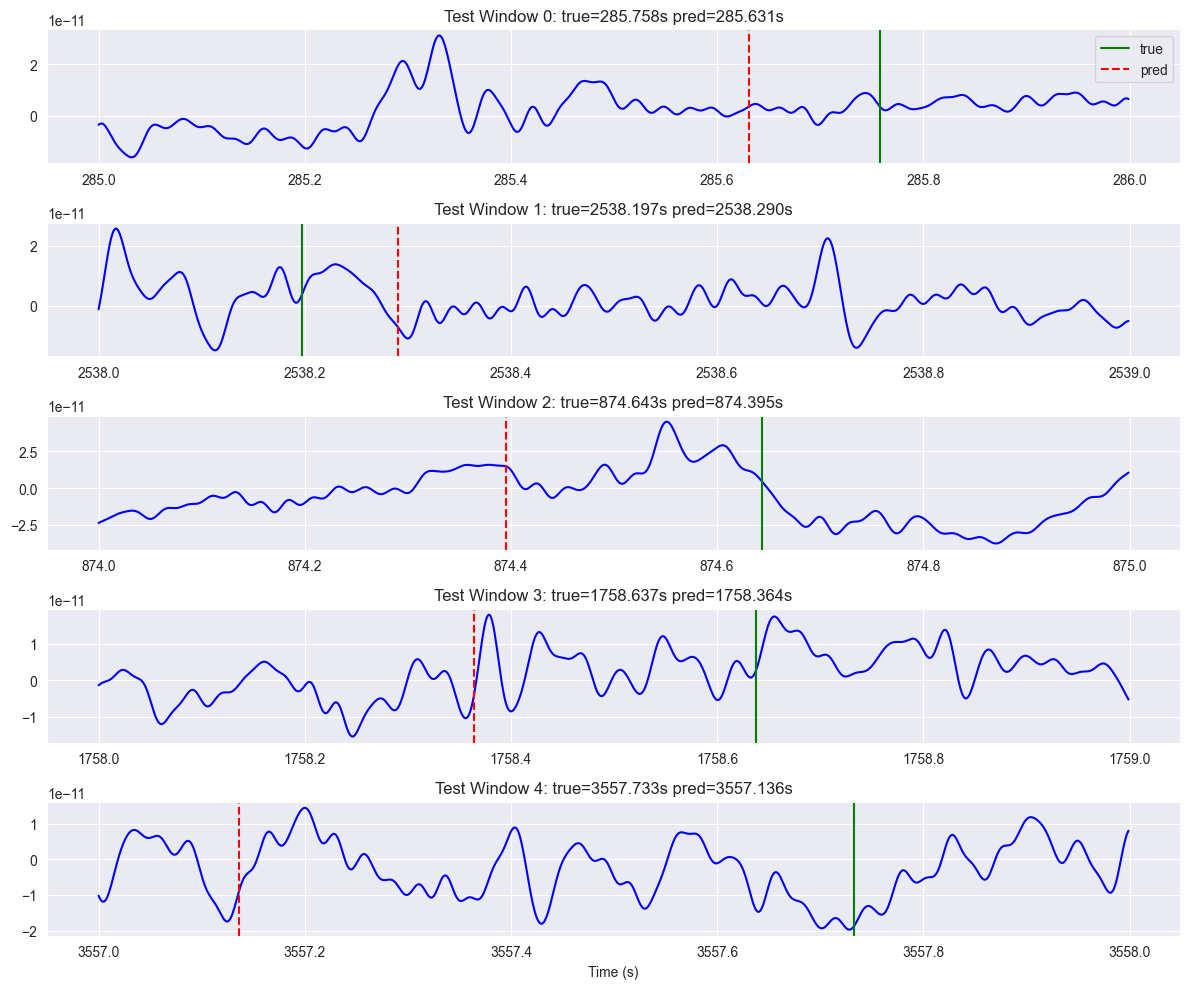

In [144]:
import matplotlib.pyplot as plt
import numpy as np

n_show = 5
plt.figure(figsize=(12, 10))

for i in range(n_show):
    # Get original window start/end
    t0 = ws_test[i]
    t1 = t0 + win_len / sfreq
    start_idx = int(t0 * sfreq)
    end_idx = int(t1 * sfreq)

    # Time vector for plotting
    t = np.arange(start_idx, end_idx) / sfreq

    # Plot the first channel (or you can loop over channels)
    plt.subplot(n_show, 1, i+1)
    plt.plot(t, signals[0, start_idx:end_idx], color='b')

    # Vertical lines: true and predicted timestamp
    plt.axvline(y_test_abs[i], linestyle='-', color='g', label='true')
    plt.axvline(y_pred_test_abs[i], linestyle='--', color='r', label='pred')

    plt.title(f"Test Window {i}: true={y_test_abs[i]:.3f}s pred={y_pred_test_abs[i]:.3f}s")
    if i == 0:
        plt.legend()

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

# 3d model on all channels

In [5]:
starts = df_behav['fix_cross.started'].dropna().values

win_sec = 1.0
win_len = int(win_sec * sfreq)
half = win_len // 2

In [43]:
mag_picks = mne.pick_types(raw.info, meg='mag')
raw_mag = raw.copy().pick(mag_picks)

selected_chs = raw_mag.ch_names

signals = raw_mag.get_data()
n_channels = signals.shape[0]

win_sec = 0.5
sfreq = raw.info['sfreq']
win_len = int(win_sec * sfreq)
n_samples = signals.shape[1]

X = []
global_feats = []
y = []
window_starts = []
bands = [(1, 4), (4,8), (8,13), (13,30), (30, 40)]

X = []
global_feats = []
y = []
window_starts = []

for start in range(0, n_samples - win_len, win_len):
    stop = start + win_len
    t0 = start / sfreq
    t1 = stop / sfreq

    inside = starts[(starts >= t0) & (starts < t1)]
    if len(inside) != 1:
        continue

    feats_per_channel = []

    for ch_idx in range(n_channels):
        w = signals[ch_idx, start:stop]

        mean_val = w.mean()
        mean_val1 = abs(w.max() - np.median(w))
        mean_val2 = abs(w.min() - np.median(w))

        median = np.median(w)
        q25, q50, q75 = np.percentile(w, [25,50,75])

        std_val = w.std()
        diff_mean = np.mean(np.diff(w))
        rms = np.sqrt(np.mean(w**2))

        diff1 = np.diff(w)
        diff2 = np.diff(diff1)

        activity = np.var(w)
        mobility = np.sqrt(np.var(diff1) / (activity + 1e-12))
        complexity = np.sqrt(np.var(diff2) / (np.var(diff1) + 1e-12)) / (mobility + 1e-12)

        freqs, psd = welch(w, fs=sfreq, nperseg=min(128, win_len))

        psd_norm = psd / (np.sum(psd) + 1e-12)
        spec_entropy = -np.sum(psd_norm * np.log(psd_norm + 1e-12))

        freq_mean = np.sum(freqs * psd) / (np.sum(psd) + 1e-12)
        spec_var = np.sum(((freqs - freq_mean)**2) * psd) / (np.sum(psd) + 1e-12)
        # spec_std = np.sqrt(spec_var)
        spec_centroid = np.sum(freqs * psd) / (np.sum(psd) + 1e-12)
        spec_bandwidth = np.sqrt(
            np.sum(((freqs - spec_centroid)**2) * psd) / (np.sum(psd) + 1e-12)
        )
        spec_flatness = np.exp(np.mean(np.log(psd + 1e-12))) / (np.mean(psd) + 1e-12)
        cumsum = np.cumsum(psd)
        rolloff = freqs[np.where(cumsum >= 0.85 * cumsum[-1])[0][0]]
        bandpowers = []
        for fmin, fmax in bands:
            mask = (freqs >= fmin) & (freqs <= fmax)
            bandpowers.append(np.trapz(psd[mask], freqs[mask]))

        feats_ch = np.hstack([
            mean_val,
            mean_val1,
            mean_val2,

            np.max(w) - median,
            median - np.min(w),
            np.median(np.abs(w - median)),   # MAD
            q75 - q25,                       # IQR
            (q75 + q25 - 2*q50)/(q75 - q25 + 1e-12),  # robust skew

            std_val,
            rms,
            diff_mean,
            activity,
            mobility,
            complexity,
            bandpowers,

            # spectral features
            spec_entropy,
            spec_var,
            freq_mean,
            spec_centroid,
            spec_bandwidth,
            spec_flatness,
            rolloff
        ]).astype(np.float32)

        feats_per_channel.append(feats_ch)

    feats_per_channel = np.array(feats_per_channel, dtype=np.float32)

    # light coherence
    # ref = 0
    # coh_feats = []
    # for j in range(1, n_channels):
    #     _, Cxy = coherence(
    #         signals[ref, start:stop],
    #         signals[j, start:stop],
    #         fs=sfreq,
    #         nperseg=min(128, win_len)
    #     )
    #     coh_feats.append(np.mean(Cxy))
    #
    # coh_feats = np.array(coh_feats, dtype=np.float32)

    X.append(feats_per_channel)
    # global_feats.append(np.hstack([coh_feats, t0, t1]).astype(np.float32))
    global_feats.append(np.hstack([t0, t1]).astype(np.float32))
    y.append((inside[0] - t0) / (t1 - t0))
    window_starts.append(t0)

/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_73505/1732243125.py:75: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bandpowers.append(np.trapz(psd[mask], freqs[mask]))


In [53]:
X.shape

(2343, 102, 26)

In [44]:
from sklearn.model_selection import train_test_split
import torch
from torch import nn
import numpy as np
import random
from scipy.stats import skew, kurtosis
from scipy.signal import coherence
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

X = np.array(X)  # (n_windows, n_channels, n_features)
global_feats = np.array(global_feats)
y = np.array(y)  # normalized [0..1]
window_starts = np.array(window_starts)

# Split train/test together
X_train, X_test, gf_train, gf_test, y_train, y_test, ws_train, ws_test = train_test_split(
    X, global_feats, y, window_starts, test_size=0.2, random_state=0
)

X_train, X_test, gf_train, gf_test, y_train, y_test = train_test_split(
    X, global_feats, y, test_size=0.2, random_state=0
)

# convert to torch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
gf_train_t = torch.tensor(gf_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
gf_test_t = torch.tensor(gf_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# DataLoader
train_dataset = TensorDataset(X_train_t, gf_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [49]:
class CNNRegression(nn.Module):
    def __init__(self, n_channels, n_features, n_global):
        super().__init__()

        self.conv1 = nn.Conv1d(n_channels, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm1d(64)

        self.pool  = nn.AdaptiveAvgPool1d(1)   # removes large flatten
        self.drop  = nn.Dropout(0.4)

        self.fc1 = nn.Linear(64 + n_global, 64)
        self.fc2 = nn.Linear(64, 32)
        self.out = nn.Linear(32, 1)

        self.relu = nn.ReLU()

    def forward(self, x, g):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))

        x = self.pool(x).squeeze(-1)   # (batch, 64)

        x = torch.cat([x, g], dim=1)

        x = self.drop(self.relu(self.fc1(x)))
        x = self.drop(self.relu(self.fc2(x)))

        return self.out(x)

model = CNNRegression(n_channels=X.shape[1], n_features=X.shape[2], n_global=gf_train.shape[1])

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-4)

In [50]:
epochs = 20
for epoch in range(epochs):
    model.train()
    running_loss = 0
    for xb, gb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb, gb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {running_loss / len(train_loader):.4f}")

Epoch 1/20, Loss: 134.7556
Epoch 2/20, Loss: 0.3588
Epoch 3/20, Loss: 0.3013
Epoch 4/20, Loss: 0.2463
Epoch 5/20, Loss: 0.2002
Epoch 6/20, Loss: 0.1630
Epoch 7/20, Loss: 0.1361
Epoch 8/20, Loss: 0.1176
Epoch 9/20, Loss: 0.1035
Epoch 10/20, Loss: 0.0952
Epoch 11/20, Loss: 0.1583
Epoch 12/20, Loss: 0.0883
Epoch 13/20, Loss: 0.0868
Epoch 14/20, Loss: 0.0851
Epoch 15/20, Loss: 0.0849
Epoch 16/20, Loss: 0.0845
Epoch 17/20, Loss: 0.0847
Epoch 18/20, Loss: 0.0844
Epoch 19/20, Loss: 0.0854
Epoch 20/20, Loss: 0.0846


## results

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

model.eval()
with torch.no_grad():
    y_pred_train_norm = model(X_train_t, gf_train_t).squeeze().numpy()
    y_pred_test_norm = model(X_test_t, gf_test_t).squeeze().numpy()

# Map back to absolute time using window starts and window duration
y_pred_train_abs = y_pred_train_norm * (win_len / sfreq) + ws_train
y_pred_test_abs = y_pred_test_norm * (win_len / sfreq) + ws_test

# If needed, get absolute y_test as well
y_train_abs = y_train * (win_len / sfreq) + ws_train
y_test_abs = y_test * (win_len / sfreq) + ws_test

mae = mean_absolute_error(y_test_abs, y_pred_test_abs)
rmse = np.sqrt(mean_squared_error(y_test_abs, y_pred_test_abs))
print("Test MAE:", mae)
print("Test RMSE:", rmse)

Test MAE: 0.11970164627996321
Test RMSE: 0.14087974225644762


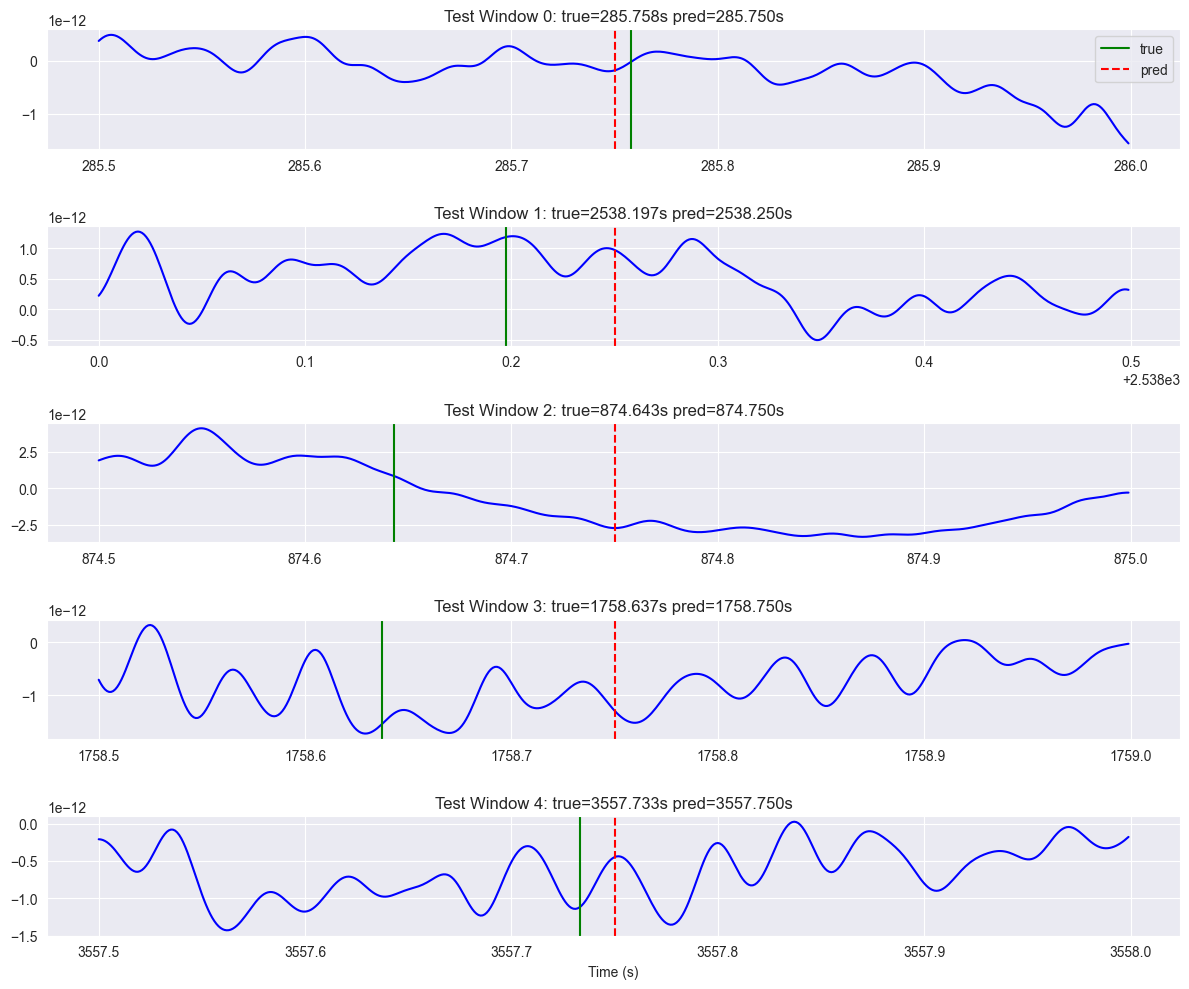

In [52]:
n_show = 5
plt.figure(figsize=(12, 10))

for i in range(n_show):
    # Get original window start/end
    t0 = ws_test[i]
    t1 = t0 + win_len / sfreq
    start_idx = int(t0 * sfreq)
    end_idx = int(t1 * sfreq)

    # Time vector for plotting
    t = np.arange(start_idx, end_idx) / sfreq

    # Plot the first channel (or you can loop over channels)
    plt.subplot(n_show, 1, i + 1)
    plt.plot(t, signals[0, start_idx:end_idx], color='b')

    # Vertical lines: true and predicted timestamp
    plt.axvline(y_test_abs[i], linestyle='-', color='g', label='true')
    plt.axvline(y_pred_test_abs[i], linestyle='--', color='r', label='pred')

    plt.title(f"Test Window {i}: true={y_test_abs[i]:.3f}s pred={y_pred_test_abs[i]:.3f}s")
    if i == 0:
        plt.legend()

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

# classification

In [81]:
starts = df_behav['fix_cross.started'].dropna().values
sfreq = raw.info['sfreq']

win_sec = 1.0
win_len = int(win_sec * sfreq)
half = win_len // 2

mag_picks = mne.pick_types(raw.info, meg='mag')
raw_mag = raw.copy().pick(mag_picks)

selected_chs = raw_mag.ch_names

signals = raw_mag.get_data()
n_channels = signals.shape[0]

win_sec = 1.0
win_len = int(win_sec * sfreq)
n_samples = signals.shape[1]

X = []
global_feats = []
y = []
window_starts = []
bands = [(1, 4), (4,8), (8,13), (13,30), (30, 40)]

X = []
global_feats = []
y = []
window_starts = []

for start in range(0, n_samples - win_len, win_len):
    stop = start + win_len
    t0 = start / sfreq
    t1 = stop / sfreq

    inside = starts[(starts >= t0) & (starts < t1)]

    label = 1 if len(inside) == 1 else 0

    feats_per_channel = []

    for ch_idx in range(n_channels):
        w = signals[ch_idx, start:stop]

        mean_val = w.mean()
        mean_val1 = abs(w.max() - np.median(w))
        mean_val2 = abs(w.min() - np.median(w))

        median = np.median(w)
        q25, q50, q75 = np.percentile(w, [25,50,75])

        std_val = w.std()
        diff_mean = np.mean(np.diff(w))
        rms = np.sqrt(np.mean(w**2))

        diff1 = np.diff(w)
        diff2 = np.diff(diff1)

        activity = np.var(w)
        mobility = np.sqrt(np.var(diff1) / (activity + 1e-12))
        complexity = np.sqrt(np.var(diff2) / (np.var(diff1) + 1e-12)) / (mobility + 1e-12)

        freqs, psd = welch(w, fs=sfreq, nperseg=min(128, win_len))

        psd_norm = psd / (np.sum(psd) + 1e-12)
        spec_entropy = -np.sum(psd_norm * np.log(psd_norm + 1e-12))

        freq_mean = np.sum(freqs * psd) / (np.sum(psd) + 1e-12)
        spec_var = np.sum(((freqs - freq_mean)**2) * psd) / (np.sum(psd) + 1e-12)
        # spec_std = np.sqrt(spec_var)
        spec_centroid = np.sum(freqs * psd) / (np.sum(psd) + 1e-12)
        spec_bandwidth = np.sqrt(
            np.sum(((freqs - spec_centroid)**2) * psd) / (np.sum(psd) + 1e-12)
        )
        spec_flatness = np.exp(np.mean(np.log(psd + 1e-12))) / (np.mean(psd) + 1e-12)
        cumsum = np.cumsum(psd)
        rolloff = freqs[np.where(cumsum >= 0.85 * cumsum[-1])[0][0]]
        # bandpowers = []
        # for fmin, fmax in bands:
        #     mask = (freqs >= fmin) & (freqs <= fmax)
        #     bandpowers.append(np.trapz(psd[mask], freqs[mask]))

        # peak position (normalized 0..1)
        peak_pos = np.argmax(np.abs(w)) / (len(w) + 1e-12)

        # energy gradient (first vs second half)
        half = len(w) // 2
        energy_first  = np.sum(w[:half]**2)
        energy_second = np.sum(w[half:]**2)
        energy_grad = (energy_second - energy_first) / (energy_first + energy_second + 1e-12)

        # slope
        x = np.arange(len(w))
        slope = np.polyfit(x, w, 1)[0]

        # peak signed position (keeps polarity info)
        peak_signed = np.argmax(w) / (len(w) + 1e-12)

        # zero-crossing density (temporal structure)
        zc = np.mean(np.diff(np.sign(w)) != 0)

        feats_ch = np.hstack([
            mean_val,
            mean_val1,
            mean_val2,

            np.max(w) - median,
            median - np.min(w),
            np.median(np.abs(w - median)),
            q75 - q25,
            (q75 + q25 - 2*q50)/(q75 - q25 + 1e-12),

            std_val,
            rms,
            diff_mean,
            activity,
            mobility,
            complexity,
            # bandpowers,

            spec_entropy,
            spec_var,
            freq_mean,
            spec_centroid,
            spec_bandwidth,
            spec_flatness,
            rolloff,

            peak_pos,
            energy_grad,
            slope,
            peak_signed,
            zc
        ]).astype(np.float32)

        feats_per_channel.append(feats_ch)

    feats_per_channel = np.array(feats_per_channel, dtype=np.float32)

    # X.append(feats_per_channel)
    # global_feats.append(np.hstack([t0, t1]).astype(np.float32))
    # y.append((inside[0] - t0) / (t1 - t0))
    # window_starts.append(t0)

    X.append(feats_per_channel)
    global_feats.append(np.hstack([t0, t1]).astype(np.float32))
    y.append(label)
    window_starts.append(t0)

In [82]:
np.unique_counts(y)

UniqueCountsResult(values=array([0, 1]), counts=array([2543, 2343]))

In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
import numpy as np

# -----------------------------
# 1. Flatten features across channels
# -----------------------------
# n_windows, n_channels, n_feats = X.shape

X = np.array(X)
global_feats = np.array(global_feats)
y = np.array(y).astype(np.float32)

X_train, X_test, gf_train, gf_test, y_train, y_test = train_test_split(
    X, global_feats, y, test_size=0.2, random_state=0, stratify=y
)

In [77]:
from sklearn.model_selection import train_test_split
import torch
from torch import nn
import numpy as np
import random
from scipy.stats import skew, kurtosis
from scipy.signal import coherence
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [78]:
from sklearn.preprocessing import StandardScaler

n_windows, n_ch, n_feat = X_train.shape

scaler = StandardScaler()
X_train_2d = X_train.reshape(-1, n_feat)
X_test_2d  = X_test.reshape(-1, n_feat)

scaler.fit(X_train_2d)

X_train = scaler.transform(X_train_2d).reshape(n_windows, n_ch, n_feat)
X_test  = scaler.transform(X_test_2d).reshape(X_test.shape)

# X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_train_t = torch.tensor(X_train.transpose(0,2,1), dtype=torch.float32)

gf_train_t = torch.tensor(gf_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

# X_test_t = torch.tensor(X_test, dtype=torch.float32)
X_test_t  = torch.tensor(X_test.transpose(0,2,1), dtype=torch.float32)
gf_test_t = torch.tensor(gf_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

X_train_t = torch.tensor(X_train_flat, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_flat, dtype=torch.float32)

train_dataset = TensorDataset(X_train_t, gf_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [58]:
class CNNClassifier(nn.Module):
    def __init__(self, n_channels, n_features, n_global):
        super().__init__()

        self.conv1 = nn.Conv1d(n_channels, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm1d(64)

        self.pool  = nn.AdaptiveAvgPool1d(1)
        self.drop  = nn.Dropout(0.4)

        self.fc1 = nn.Linear(64 + n_global, 64)
        self.fc2 = nn.Linear(64, 32)
        self.out = nn.Linear(32, 1)

        self.relu = nn.ReLU()

    def forward(self, x, g):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))

        x = self.pool(x).squeeze(-1)
        x = torch.cat([x, g], dim=1)

        x = self.drop(self.relu(self.fc1(x)))
        x = self.drop(self.relu(self.fc2(x)))

        return self.out(x)   # logits

In [64]:
class MLPClassifier(nn.Module):
    def __init__(self, n_in, n_global):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_in + n_global, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x, g):
        x = torch.cat([x, g], dim=1)
        return self.net(x)

In [68]:
# model = CNNClassifier(
#     n_channels=X.shape[2],   # features
#     n_features=X.shape[1],   # not used but keep for consistency
#     n_global=gf_train.shape[1]
# )
model = MLPClassifier(
    n_in=X_train_flat.shape[1],
    n_global=gf_train.shape[1]
)
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
pos_weight = torch.tensor([n_neg / (n_pos + 1e-12)], dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss()#pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

clf = LogisticRegression(max_iter=5000)
clf.fit(X_train_flat, y_train)

probs = clf.predict_proba(X_test_flat)[:,1]
print("LogReg ROC-AUC:", roc_auc_score(y_test, probs))

/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


LogReg ROC-AUC: 0.5417118728557605


/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [86]:
pos = X_train[y_train==1].reshape(-1, X_train.shape[-1])
neg = X_train[y_train==0].reshape(-1, X_train.shape[-1])

diff = np.abs(pos.mean(0) - neg.mean(0))
print("mean feature diff:", diff.mean())

mean feature diff: 0.017010352


In [66]:
with torch.no_grad():
    logits = model(X_train_t[:128], gf_train_t[:128])
    print("initial logits std:", logits.std())

initial logits std: tensor(3.9861)


In [69]:
for epoch in range(10):
    model.train()
    total_loss = 0

    for xb, gb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb, gb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}: loss={total_loss/len(train_loader):.4f}")

Epoch 0: loss=0.6718
Epoch 1: loss=0.5746
Epoch 2: loss=0.5620
Epoch 3: loss=0.5600
Epoch 4: loss=0.5517
Epoch 5: loss=0.5480
Epoch 6: loss=0.5484
Epoch 7: loss=0.5463
Epoch 8: loss=0.5440
Epoch 9: loss=0.5427


In [70]:
with torch.no_grad():
    logits = model(X_train_t[:200], gf_train_t[:200])
    print("logits std:", logits.std())

logits std: tensor(1.2819)


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

model.eval()
with torch.no_grad():
    logits = model(X_test_t, gf_test_t)
    probs = torch.sigmoid(logits).cpu().numpy().ravel()
    preds = (probs > 0.5).astype(int)

y_true = y_test

print("Accuracy :", accuracy_score(y_true, preds))
print("Precision:", precision_score(y_true, preds))
print("Recall   :", recall_score(y_true, preds))
print("F1       :", f1_score(y_true, preds))
print("ROC AUC  :", roc_auc_score(y_true, probs))

cm = confusion_matrix(y_true, preds)
print("\nConfusion matrix:\n", cm)

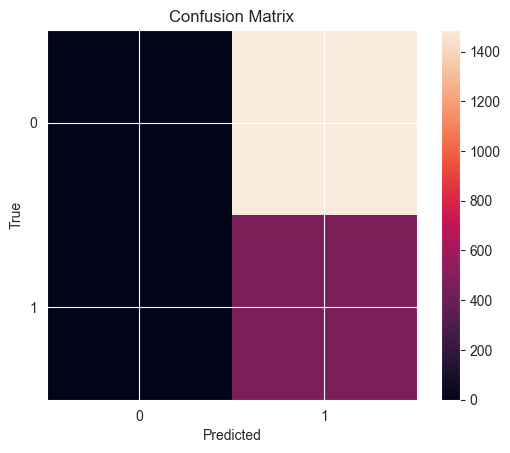

In [34]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0,1])
plt.yticks([0,1])
plt.colorbar()
plt.show()